In [2]:
from qiskit import QuantumCircuit
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import eigh
import time

%matplotlib inline

Original Circuit


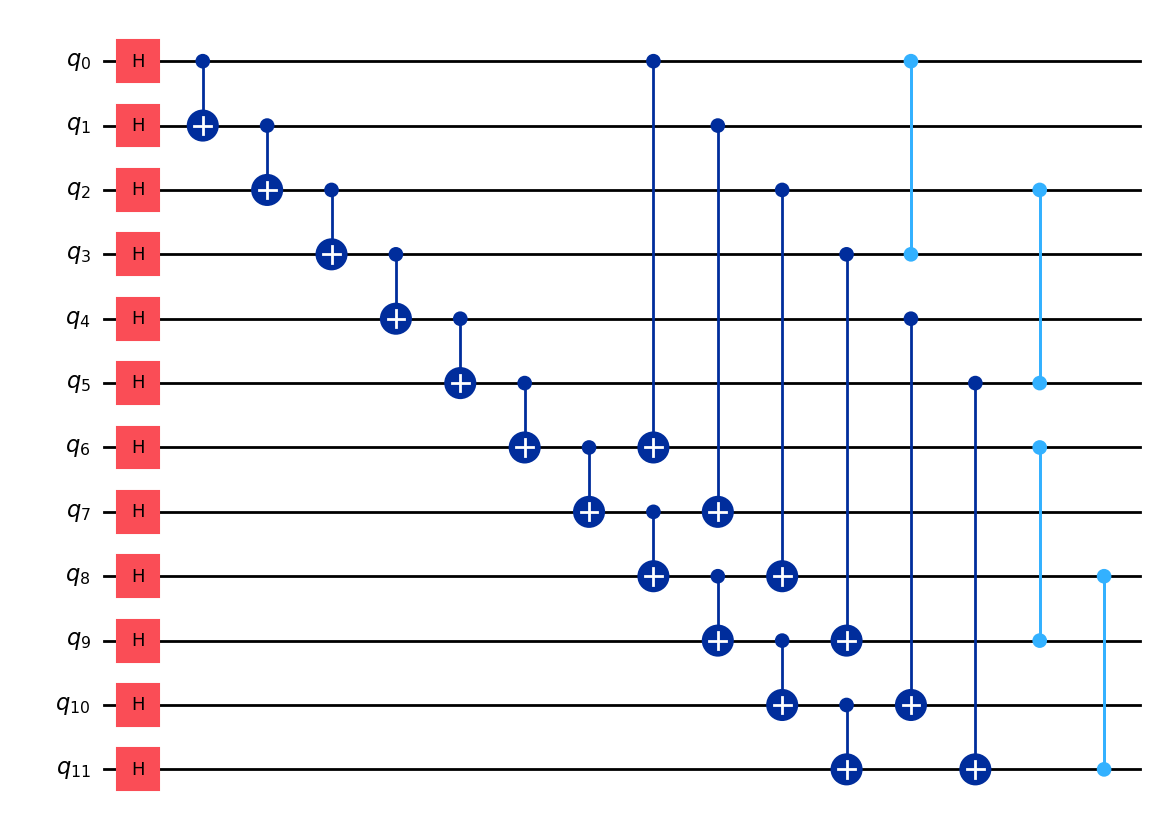

In [3]:
qc = QuantumCircuit(12)

for i in range(12):
    qc.h(i)

for i in range(11):
    qc.cx(i, i + 1)

qc.cx(0, 6)
qc.cx(1, 7)
qc.cx(2, 8)
qc.cx(3, 9)
qc.cx(4, 10)
qc.cx(5, 11)

qc.cz(0, 3)
qc.cz(2, 5)
qc.cz(6, 9)
qc.cz(8, 11)

print("Original Circuit")
qc.draw("mpl")
plt.show()

In [4]:
G = nx.Graph()

for q in range(qc.num_qubits):
    G.add_node(q)

for instruction in qc.data:

    if len(instruction.qubits) == 2:

        q0 = qc.qubits.index(instruction.qubits[0])
        q1 = qc.qubits.index(instruction.qubits[1])

        gate_name = instruction.operation.name

        G.add_edge(q0, q1, gate=gate_name)

print("Nodes =", list(G.nodes()))
print("Edges =", list(G.edges()))

Nodes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Edges = [(0, 1), (0, 6), (0, 3), (1, 2), (1, 7), (2, 3), (2, 8), (2, 5), (3, 4), (3, 9), (4, 5), (4, 10), (5, 6), (5, 11), (6, 7), (6, 9), (7, 8), (8, 9), (8, 11), (9, 10), (10, 11)]


In [5]:
start = time.time()

# Laplacian Matrix
L = nx.laplacian_matrix(G).toarray()

# Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = eigh(L)

# Fiedler Vector
fiedler_vector = eigenvectors[:, 1]

partA = set()
partB = set()

for node, value in enumerate(fiedler_vector):

    if value >= 0:
        partA.add(node)
    else:
        partB.add(node)

end = time.time()

print("\nGroup A =", sorted(partA))
print("Group B =", sorted(partB))


Group A = [0, 1, 2, 3, 6, 7, 8]
Group B = [4, 5, 9, 10, 11]


In [6]:
cut_edges = []

for u, v, data in G.edges(data=True):

    if (u in partA and v in partB) or \
       (u in partB and v in partA):

        cut_edges.append((u, v, data["gate"]))

minimum_cut_count = len(cut_edges)

print("\nCut Gates:")

for u, v, gate in cut_edges:
    print(f"{gate.upper()} between q{u} and q{v}")

print("\nTotal Cuts =", minimum_cut_count)


Cut Gates:
CZ between q2 and q5
CX between q3 and q4
CX between q3 and q9
CX between q5 and q6
CZ between q6 and q9
CX between q8 and q9
CZ between q8 and q11

Total Cuts = 7


In [7]:
def extract_subcircuit(circuit, qubit_group, name):

    ordered = sorted(qubit_group)

    mapping = {}

    for new, old in enumerate(ordered):
        mapping[old] = new

    sub = QuantumCircuit(len(qubit_group), name=name)

    for instruction in circuit.data:

        indices = []

        for q in instruction.qubits:
            indices.append(circuit.qubits.index(q))

        if all(i in qubit_group for i in indices):

            sub.append(
                instruction.operation,
                [mapping[i] for i in indices]
            )

    return sub



Subcircuit A


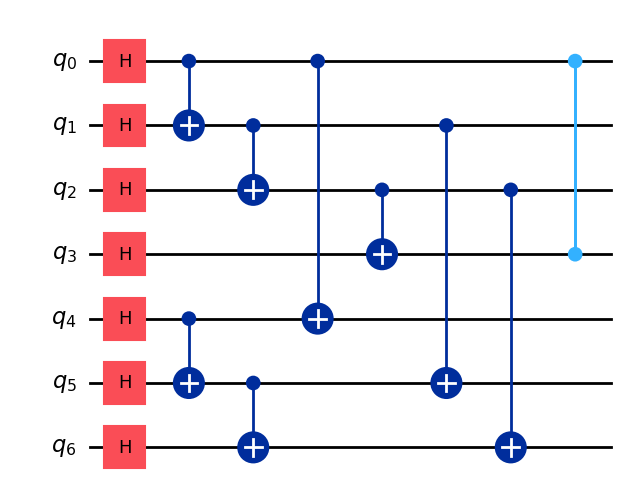


Subcircuit B


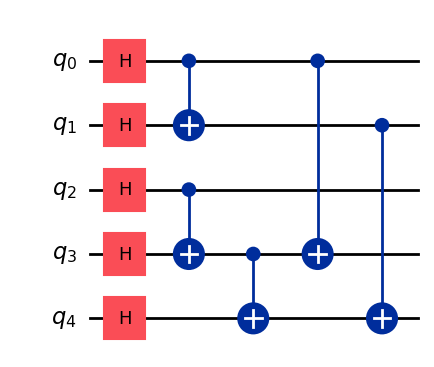

In [8]:
subA = extract_subcircuit(qc, partA, "SubA")
subB = extract_subcircuit(qc, partB, "SubB")

print("\nSubcircuit A")
subA.draw("mpl")
plt.show()

print("\nSubcircuit B")
subB.draw("mpl")
plt.show()

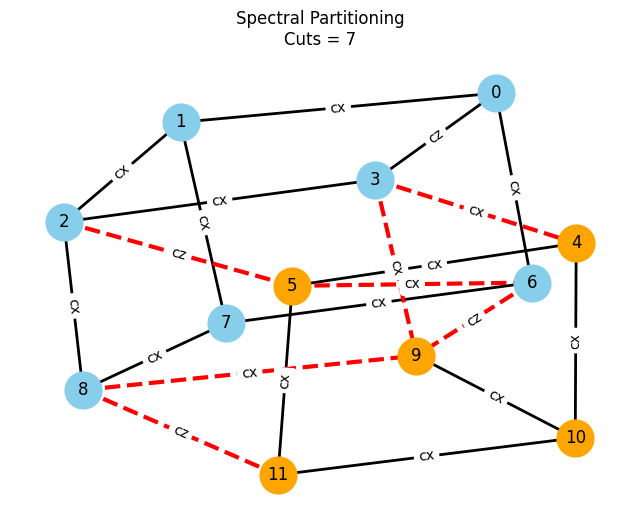

In [9]:
plt.figure(figsize=(8, 6))

pos = nx.spring_layout(G, seed=42)

cut_only = [(u, v) for u, v, gate in cut_edges]

normal_edges = []

for e in G.edges():

    if e not in cut_only and (e[1], e[0]) not in cut_only:
        normal_edges.append(e)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(partA),
    node_color="skyblue",
    node_size=700
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(partB),
    node_color="orange",
    node_size=700
)

nx.draw_networkx_labels(G, pos)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=normal_edges,
    width=2
)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=cut_only,
    edge_color="red",
    style="dashed",
    width=3
)

edge_labels = nx.get_edge_attributes(G, "gate")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title(
    f"Spectral Partitioning\nCuts = {minimum_cut_count}"
)

plt.axis("off")
plt.show()


In [11]:
runtime = end - start

print("Runtime =", runtime, "seconds")

Runtime = 2.1195569038391113 seconds
